In [1]:
from tensorflow.keras.datasets import cifar10
import numpy as np

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Flatten labels
y_train = y_train.flatten()

# Normalize
x_train = x_train / 255.0

print("Shape:", x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Shape: (50000, 32, 32, 3)


In [2]:
def rgb_to_gray(images):
    # Using standard luminance formula
    return np.dot(images[...,:3], [0.2989, 0.5870, 0.1140])

x_train_gray = rgb_to_gray(x_train)

In [3]:
from skimage.feature import local_binary_pattern

def extract_lbp_features(image):
    radius = 1
    n_points = 8 * radius

    lbp = local_binary_pattern(image, n_points, radius, method='uniform')

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist

In [4]:
num_samples = 2000  # CIFAR is heavier

features = []
labels = []

for i in range(num_samples):
    feat = extract_lbp_features(x_train_gray[i])
    features.append(feat)
    labels.append(y_train[i])

features = np.array(features)
labels = np.array(labels)

print("Feature shape:", features.shape)

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Feature shape: (2000, 10)


In [5]:
from sklearn.metrics.pairwise import euclidean_distances

def retrieve_similar_images(query_img, features, top_k=5):

    query_feat = extract_lbp_features(query_img)

    dists = euclidean_distances([query_feat], features)[0]

    indices = np.argsort(dists)[:top_k]

    return indices

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


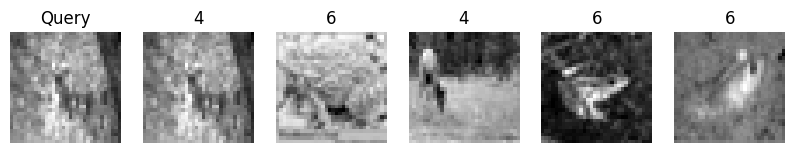

In [6]:
import matplotlib.pyplot as plt

query_index = 10
query_img = x_train_gray[query_index]

indices = retrieve_similar_images(query_img, features, top_k=5)

plt.figure(figsize=(10,3))

# Query
plt.subplot(1,6,1)
plt.imshow(query_img, cmap='gray')
plt.title("Query")
plt.axis('off')

# Results
for i, idx in enumerate(indices):
    plt.subplot(1,6,i+2)
    plt.imshow(x_train_gray[idx], cmap='gray')
    plt.title(f"{labels[idx]}")
    plt.axis('off')

plt.show()

In [7]:
precision, recall, mAP = evaluate_system(x_train_gray[:2000], labels, features)

print_evaluation_table(precision, recall, mAP)

NameError: name 'evaluate_system' is not defined

In [8]:
import numpy as np

# Precision & Recall
def compute_precision_recall(query_label, retrieved_indices, labels):

    relevant = 0
    for idx in retrieved_indices:
        if labels[idx] == query_label:
            relevant += 1

    precision = relevant / len(retrieved_indices)

    total_relevant = np.sum(labels == query_label)
    recall = relevant / total_relevant

    return precision, recall

In [9]:
# Average Precision (AP)
def compute_ap(query_label, retrieved_indices, labels):

    correct = 0
    precision_sum = 0

    for i, idx in enumerate(retrieved_indices):
        if labels[idx] == query_label:
            correct += 1
            precision_at_i = correct / (i + 1)
            precision_sum += precision_at_i

    if correct == 0:
        return 0

    return precision_sum / correct


In [10]:
# Main Evaluation Function
def evaluate_system(x_data, labels, features, num_queries=100, top_k=5):

    precisions = []
    recalls = []
    aps = []

    for i in range(num_queries):

        query_img = x_data[i]
        query_label = labels[i]

        retrieved = retrieve_similar_images(query_img, features, top_k)

        p, r = compute_precision_recall(query_label, retrieved, labels)
        ap = compute_ap(query_label, retrieved, labels)

        precisions.append(p)
        recalls.append(r)
        aps.append(ap)

    return np.mean(precisions), np.mean(recalls), np.mean(aps)

In [11]:
precision, recall, mAP = evaluate_system(x_train_gray[:2000], labels, features)

print_evaluation_table(precision, recall, mAP)

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3

NameError: name 'print_evaluation_table' is not defined

In [12]:
def print_evaluation_table(precision, recall, mAP):

    print("\nComparative Analysis\n")

    print("{:<10} {:<10} {:<10} {:<10} {:<15} {:<40}".format(
        "Method", "Precision", "Recall", "mAP", "Robustness", "Remarks"
    ))

    print("-" * 100)

    print("{:<10} {:<10.2f} {:<10.2f} {:<10.2f} {:<15} {:<40}".format(
        "LBP",
        precision,
        recall,
        mAP,
        "Low",
        "Texture-based, poor semantic understanding (CIFAR)"
    ))

In [13]:
precision, recall, mAP = evaluate_system(x_train_gray[:2000], labels, features)

print_evaluation_table(precision, recall, mAP)


Comparative Analysis

Method     Precision  Recall     mAP        Robustness      Remarks                                 
----------------------------------------------------------------------------------------------------
LBP        0.32       0.01       0.93       Low             Texture-based, poor semantic understanding (CIFAR)


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3